In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [73]:
Sal_data = pd.read_csv("Salary.csv")

In [74]:
Sal_data.head()

,Age,YearsExperience,EducationLevel,Salary
0,28,1,Master,56512
1,35,8,Master,91587
2,55,5,Bachelor,70520
3,22,1,Bachelor,47779
4,59,1,Bachelor,69731


EDA

In [75]:
Sal_data.shape

(2000, 4)

In [76]:
Sal_data.columns

Index(['Age', 'YearsExperience', 'EducationLevel', 'Salary'], dtype='str')

In [77]:
Sal_data.columns = ["Age","Experience_year","Education_level","Salary"]

In [78]:
Sal_data.dtypes

Age                int64
Experience_year    int64
Education_level      str
Salary             int64
dtype: object

In [79]:
Sal_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              2000 non-null   int64
 1   Experience_year  2000 non-null   int64
 2   Education_level  2000 non-null   str  
 3   Salary           2000 non-null   int64
dtypes: int64(3), str(1)
memory usage: 77.1 KB


In [80]:
Sal_data[Sal_data.duplicated()]

,Age,Experience_year,Education_level,Salary
1825,38,17,Bachelor,107419


In [81]:
Sal_data = Sal_data.drop_duplicates(keep="first")

In [82]:
Sal_data.isnull().sum()

Age                0
Experience_year    0
Education_level    0
Salary             0
dtype: int64

In [83]:
Sal_data.dropna(how ="any", inplace=True)

In [84]:
Sal_data.shape

(1999, 4)

In [85]:
Sal_data.describe()

,Age,Experience_year,Salary
count,1999.000000,1999.00000,1999.000000
mean,41.078539,12.93997,102085.981991
std,11.463103,9.52119,37876.918264
min,21.000000,0.00000,29100.000000
25%,31.000000,5.00000,71000.500000
50%,41.000000,11.00000,96293.000000
75%,51.000000,20.00000,129873.000000
max,60.000000,39.00000,221269.000000


In [86]:
corr = Sal_data[["Age","Experience_year","Salary"]].corr()
corr

,Age,Experience_year,Salary
Age,1.000000,0.576688,0.643000
Experience_year,0.576688,1.000000,0.959556
Salary,0.643000,0.959556,1.000000


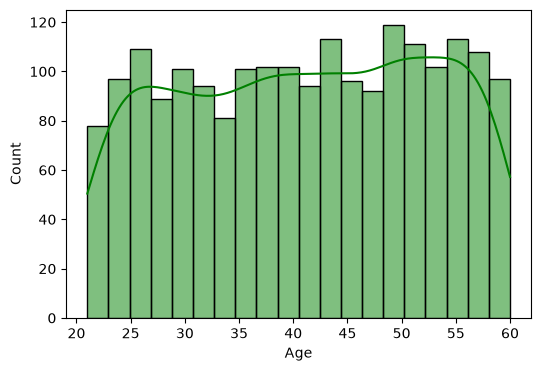

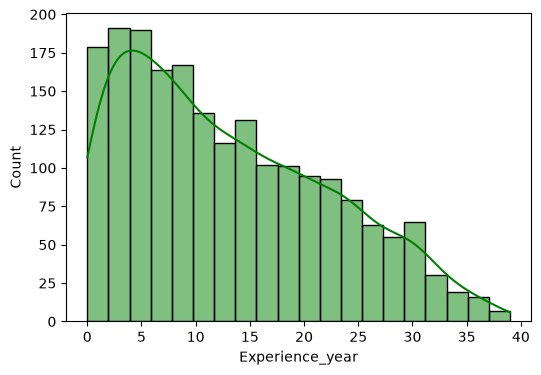

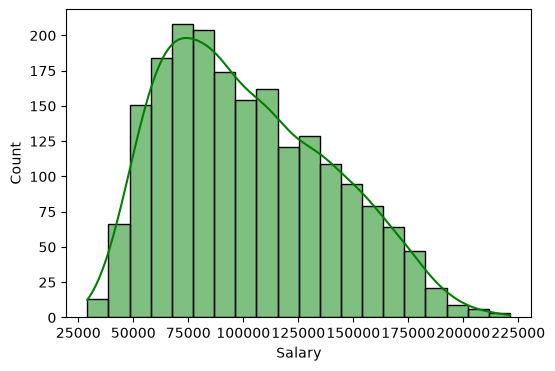

In [87]:
numerical_col = ['Age', 'Experience_year', 'Salary']
for col in numerical_col:
    plt.figure(figsize=(6,4))
    sns.histplot(Sal_data[col], kde = True, bins=20, color = 'green')

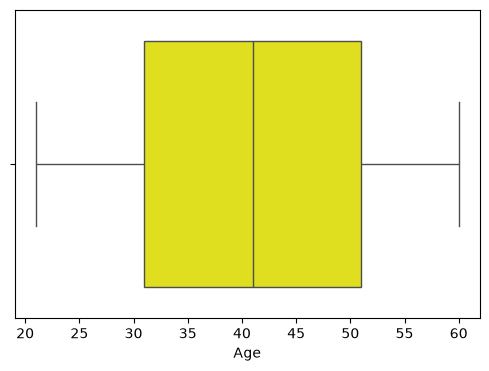

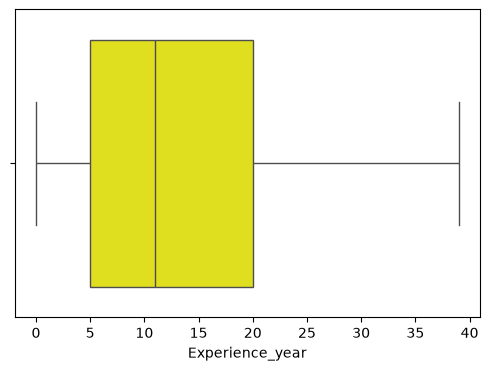

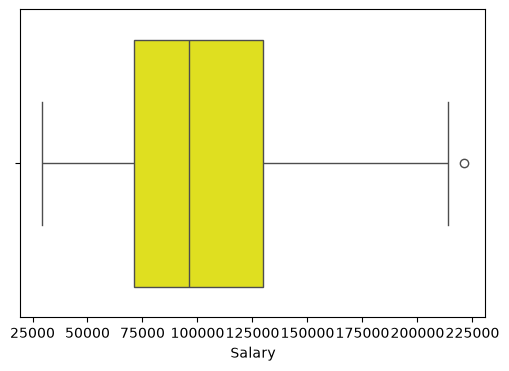

In [88]:
numerical_col = ['Age', 'Experience_year', 'Salary']
for col in numerical_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=Sal_data[col],color='yellow')

<Axes: >

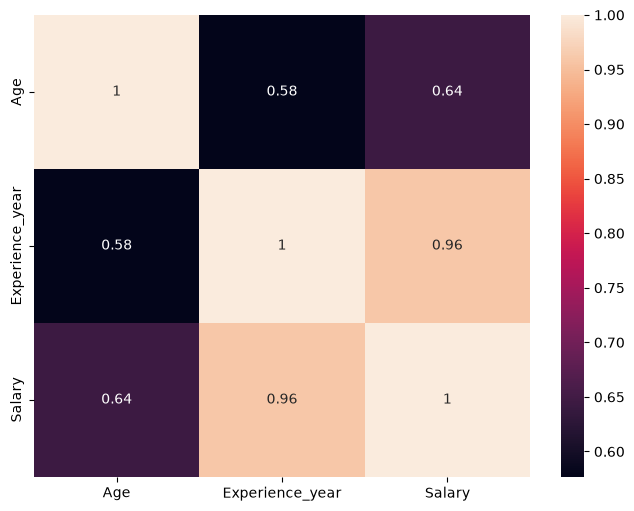

In [89]:
plt.figure(figsize=(8,6))
sns.heatmap(Sal_data.corr(numeric_only=True),annot=True)

<Axes: xlabel='Education_level', ylabel='count'>

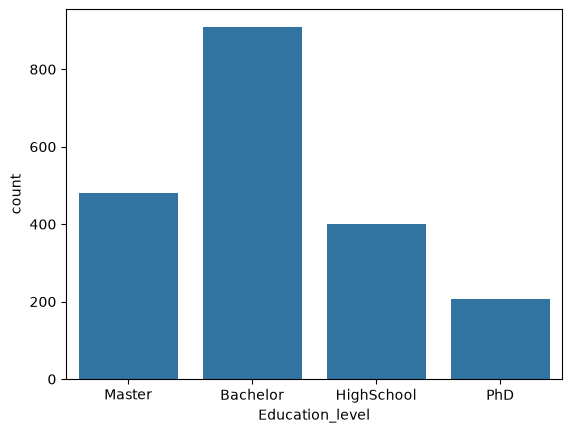

In [90]:
sns.countplot(x = Sal_data['Education_level'])

In [91]:
Sal_data["Education_level"].value_counts()

Education_level
Bachelor      909
Master        481
HighSchool    401
PhD           208
Name: count, dtype: int64

In [92]:
Sal_data = pd.get_dummies(Sal_data, columns = ["Education_level"], drop_first = True)

In [93]:
Sal_data.columns

Index(['Age', 'Experience_year', 'Salary', 'Education_level_HighSchool',
       'Education_level_Master', 'Education_level_PhD'],
      dtype='str')

In [94]:
Sal_data.head()

,Age,Experience_year,Salary,Education_level_HighSchool,Education_level_Master,Education_level_PhD
0,28,1,56512,False,True,False
1,35,8,91587,False,True,False
2,55,5,70520,False,False,False
3,22,1,47779,False,False,False
4,59,1,69731,False,False,False


In [95]:
Sal_data = Sal_data.astype(int)

In [96]:
Sal_data.head()

,Age,Experience_year,Salary,Education_level_HighSchool,Education_level_Master,Education_level_PhD
0,28,1,56512,0,1,0
1,35,8,91587,0,1,0
2,55,5,70520,0,0,0
3,22,1,47779,0,0,0
4,59,1,69731,0,0,0


In [97]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols=['Age', 'Experience_year']               #standerd scalling for getting better results
scaler= StandardScaler()            

Sal_data[cols]=scaler.fit_transform(Sal_data[cols])

In [98]:
Sal_data.head()

,Age,Experience_year,Salary,Education_level_HighSchool,Education_level_Master,Education_level_PhD
0,-1.141210,-1.254356,56512,0,1,0
1,-0.530403,-0.518969,91587,0,1,0
2,1.214762,-0.834135,70520,0,0,0
3,-1.664760,-1.254356,47779,0,0,0
4,1.563795,-1.254356,69731,0,0,0


In [99]:
x = Sal_data.drop('Salary', axis =1)
y = Sal_data['Salary']

In [100]:
from sklearn.model_selection import train_test_split



In [101]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.20, random_state=42)

In [103]:
from sklearn.linear_model import LinearRegression

Linear_regression_model = LinearRegression()
Linear_regression_model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 5444.53,33471.65,-7980.9 , 9985.41,22049.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Age','Experience_year','Education_level_HighSchool', 'Education_level_Master','Education_level_PhD']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9.907e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [ ]:
y_pred = Linear_regression_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.9697339796977046
MAE      : 5503.395859162856
RMSE     : 6973.703818799209


In [104]:
import joblib

joblib.dump(Linear_regression_model, "salary_model.pkl")
joblib.dump(scaler, "salary_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
